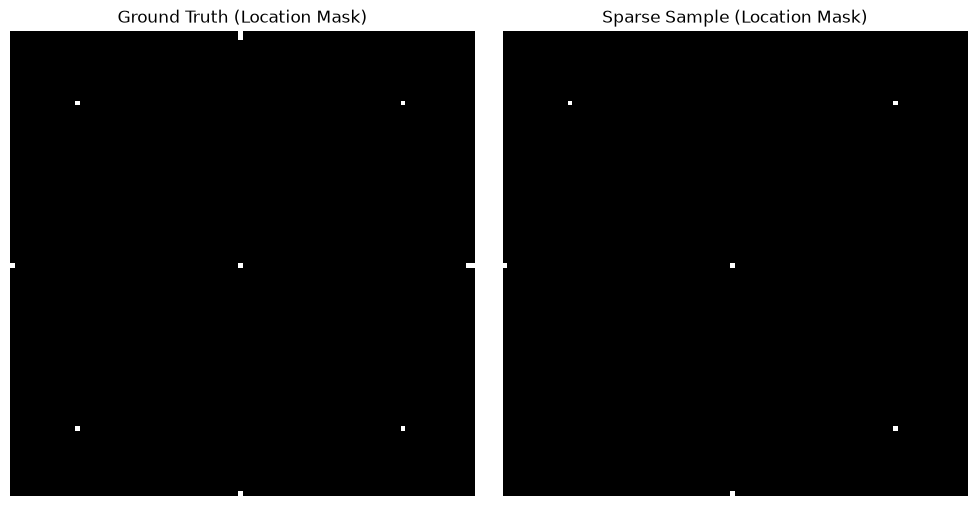

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a helper function to read the C++ binary files
def load_bin_image(filepath, size=100):
    data = np.fromfile(filepath, dtype=np.float32)
    return data.reshape((size, size))

# 2. Load the raw floating-point math
ground_truth_raw = load_bin_image("ml_dataset/ground_truth.bin")
sample_0_raw = load_bin_image("ml_dataset/sample_0.bin")

# 3. Convert raw floats into Binary Masks (1s and 0s) for the "Location" problem
gt_mask = (ground_truth_raw > 0).astype(float)
sample_mask = (sample_0_raw > 0).astype(float)

# 4. Visualize the Binary Masks (with 'nearest' interpolation to show true 1x1 pixels)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Ground Truth Mask
axes[0].imshow(gt_mask, cmap='gray', origin='lower', interpolation='nearest')
axes[0].set_title("Ground Truth (Location Mask)")
axes[0].axis('off')

# Plot Sample Mask
axes[1].imshow(sample_mask, cmap='gray', origin='lower', interpolation='nearest')
axes[1].set_title("Sparse Sample (Location Mask)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

class QuantumLocationDataset(Dataset):
    def __init__(self, data_dir, num_samples=1000, grid_size=100):
        self.data_dir = data_dir
        self.num_samples = num_samples
        self.grid_size = grid_size
        
        # Load the Ground Truth once (since the target is exactly the same for every sample)
        gt_raw = np.fromfile(os.path.join(data_dir, "ground_truth.bin"), dtype=np.float32)
        
        # Convert to mask (1s and 0s) and add a "Channel" dimension (1, 100, 100) for PyTorch
        gt_mask = (gt_raw > 0).astype(np.float32).reshape(1, grid_size, grid_size)
        self.gt_tensor = torch.tensor(gt_mask)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Load the specific random sample requested by the DataLoader
        sample_path = os.path.join(self.data_dir, f"sample_{idx}.bin")
        sample_raw = np.fromfile(sample_path, dtype=np.float32)
        
        # Convert to mask and reshape to (1, 100, 100)
        sample_mask = (sample_raw > 0).astype(np.float32).reshape(1, self.grid_size, self.grid_size)
        
        return torch.tensor(sample_mask), self.gt_tensor

# 1. Initialize the dataset
dataset = QuantumLocationDataset("ml_dataset", num_samples=1000)

# 2. Create the DataLoader (batches of 16, and shuffling to prevent MCMC bias!)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# 3. Test it out to make sure the tensor shapes are correct
sample_batch, gt_batch = next(iter(dataloader))
print(f"Sample batch shape: {sample_batch.shape} -> [Batch_Size, Channels, Height, Width]")
print(f"Ground truth batch shape: {gt_batch.shape}")

Sample batch shape: torch.Size([16, 1, 100, 100]) -> [Batch_Size, Channels, Height, Width]
Ground truth batch shape: torch.Size([16, 1, 100, 100])


In [13]:
import torch.nn as nn
import torch

class QuantumUNet(nn.Module):
    def __init__(self):
        super(QuantumUNet, self).__init__()
        
        # --- ENCODER ---
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2) 
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2) 
        
        # --- BOTTLENECK ---
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        
        # --- DECODER (FIX: Smooth Bilinear Upsampling) ---
        self.upconv2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(64, 32, kernel_size=1)
        )
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True), 
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        
        self.upconv1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(32, 16, kernel_size=1)
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True), 
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        b = self.bottleneck(p2)
        
        u2 = self.upconv2(b)
        u2 = torch.cat((u2, e2), dim=1) 
        d2 = self.dec2(u2)
        
        u1 = self.upconv1(d2)
        u1 = torch.cat((u1, e1), dim=1)
        d1 = self.dec1(u1)
        
        out = self.final_conv(d1)
        return out

model = QuantumUNet()

--- Starting Stable Training Loop ---
Epoch [1/10] - Loss: 0.23918
Epoch [2/10] - Loss: 0.11012
Epoch [3/10] - Loss: 0.09196
Epoch [4/10] - Loss: 0.08703
Epoch [5/10] - Loss: 0.08466
Epoch [6/10] - Loss: 0.08455
Epoch [7/10] - Loss: 0.08318
Epoch [8/10] - Loss: 0.08206
Epoch [9/10] - Loss: 0.08114
Epoch [10/10] - Loss: 0.08053

=== Training Complete! ===


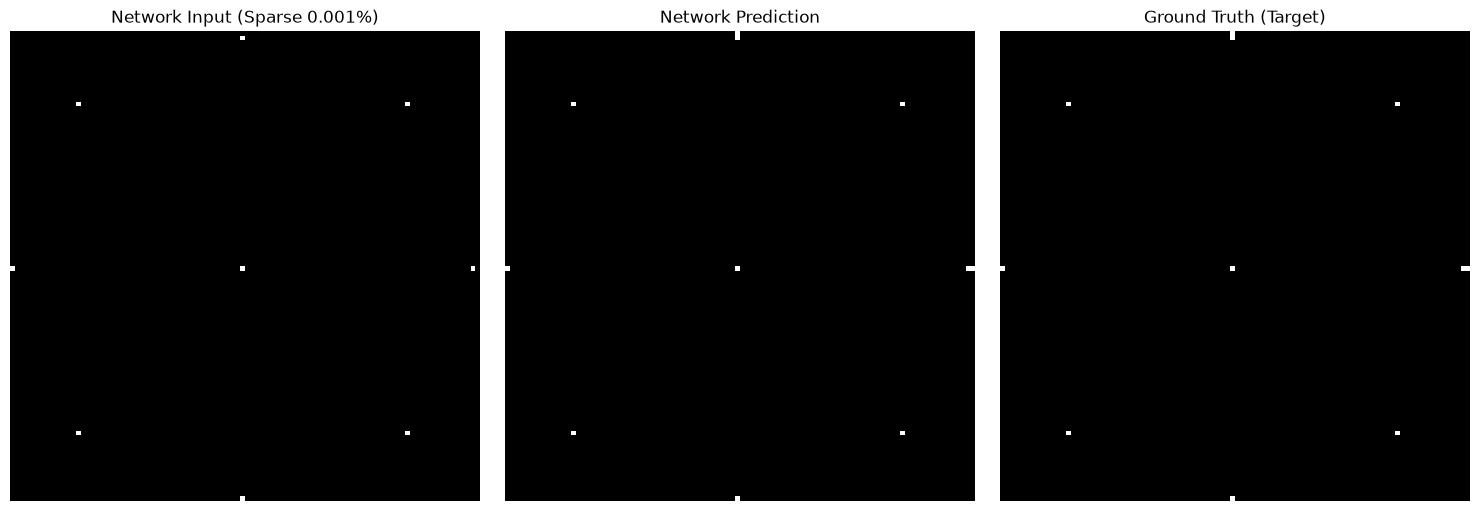

In [14]:
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

# FIX: Lower the paranoia weight from 900.0 to 100.0
weight = torch.tensor([100.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weight)

optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 10

print("--- Starting Stable Training Loop ---")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.5f}")

print("\n=== Training Complete! ===")

# Visualize the AI's Prediction
model.eval()
with torch.no_grad():
    test_inputs, test_targets = next(iter(dataloader))
    test_inputs = test_inputs.to(device)
    
    test_preds = torch.sigmoid(model(test_inputs))
    
    in_img = test_inputs[0, 0].cpu().numpy()
    gt_img = test_targets[0, 0].numpy() 
    
    # Keep the strict 90% confidence threshold!
    pred_img = (test_preds[0, 0].cpu().numpy() > 0.9).astype(float)

# Plot the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(in_img, cmap='gray', interpolation='nearest', origin='lower')
axes[0].set_title("Network Input (Sparse 0.001%)")
axes[0].axis('off')

axes[1].imshow(pred_img, cmap='gray', interpolation='nearest', origin='lower')
axes[1].set_title("Network Prediction")
axes[1].axis('off')

axes[2].imshow(gt_img, cmap='gray', interpolation='nearest', origin='lower')
axes[2].set_title("Ground Truth (Target)")
axes[2].axis('off')

plt.tight_layout()
plt.show()